In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Predicción de Abandono de Clientes (Customer Churn)

## Problema de Negocio

La pérdida de clientes representa uno de los principales desafíos para las empresas que ofrecen servicios por suscripción.

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de predecir si un cliente abandonará la empresa utilizando información demográfica, servicios contratados y características de facturación.

## Objetivos del Proyecto

- Comprender el comportamiento de los clientes.
- Identificar los factores relacionados con el abandono de clientes.
- Construir modelos de Machine Learning para predecir el churn.
- Comparar el rendimiento de distintos modelos.
- Proporcionar recomendaciones de negocio basadas en los resultados obtenidos.

## Hipótesis

### H1
Los clientes con contratos mensuales tienen una mayor probabilidad de abandonar la empresa.

### H2
Los clientes con cargos mensuales más elevados presentan una mayor tasa de abandono.

### H3
Los clientes con menor antigüedad en la compañía tienen más probabilidades de cancelar el servicio.

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Conclusión Inicial

La mayoría de los clientes permanecen en la compañía.

Aproximadamente el 73.46% de los clientes continúan utilizando los servicios, mientras que el 26.54% han abandonado la empresa.

Esto indica que existe cierto desbalance entre las clases, aunque sigue siendo adecuado para construir modelos de clasificación.

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Resumen del Día 1

Se seleccionó el problema de negocio Customer Churn y se obtuvo el dataset correspondiente.

Se realizó una exploración inicial de los datos para comprender su estructura, identificar las variables disponibles y analizar la distribución de la variable objetivo.

Además, se plantearon tres hipótesis relacionadas con el tipo de contrato, los cargos mensuales y la antigüedad de los clientes que serán evaluadas durante el análisis exploratorio y la construcción de modelos de Machine Learning.

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Data Quality Assessment

Se verificó la existencia de valores nulos y registros duplicados en el dataset.

No se encontraron valores faltantes ni filas duplicadas, por lo que no fue necesario aplicar técnicas de imputación o eliminación de registros.

Esto permite continuar con el proceso de preparación de datos para Machine Learning.

In [12]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [14]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [17]:
df['TotalCharges'].dtype

dtype('O')

In [18]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [19]:
df['TotalCharges'].dtype

dtype('float64')

In [20]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [21]:
df = df.dropna()

In [22]:
df.shape

(7032, 21)

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## TotalCharges Data Cleaning

La variable TotalCharges fue identificada como una columna de tipo object a pesar de contener información numérica.

Se convirtió a formato numérico utilizando pd.to_numeric().

Durante este proceso se detectaron 11 valores faltantes, que representan menos del 1% del dataset.

Debido a su baja proporción, estos registros fueron eliminados para evitar problemas durante el entrenamiento de los modelos de Machine Learning.

In [24]:
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [25]:
df = df.drop('customerID', axis=1)

In [26]:
df.shape

(7032, 20)

In [27]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [28]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [29]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

In [30]:
df['PhoneService'].value_counts()

PhoneService
Yes    6352
No      680
Name: count, dtype: int64

In [31]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

In [32]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [33]:
binary_columns = ['Partner', 'Dependents', 'PhoneService',
                  'PaperlessBilling', 'Churn']

for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [34]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [35]:
df[['gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn']].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [36]:
multi_cat_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

for col in multi_cat_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

TechSupport
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

StreamingMovies
StreamingMovies
No                     27

In [37]:
df_encoded = df.copy()

In [38]:
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True
)

In [39]:
df_encoded.shape

(7032, 31)

In [40]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## Feature Engineering

En esta fase se prepararon las variables para su utilización en modelos de Machine Learning.

Las variables binarias fueron transformadas a valores numéricos (0 y 1), mientras que las variables categóricas con múltiples categorías fueron codificadas mediante One-Hot Encoding.

Además, se eliminó la columna `customerID`, ya que se trata de un identificador único sin valor predictivo para el problema de clasificación.

Como resultado, el dataset quedó completamente numérico y listo para la fase de entrenamiento de modelos.

## Definición de Variables

Una vez finalizado el proceso de limpieza y transformación de datos, se definieron las variables predictoras (X) y la variable objetivo (y).

Las variables predictoras contienen la información utilizada para realizar las predicciones, mientras que la variable objetivo corresponde a la columna Churn, que indica si un cliente abandonó la compañía o no.

In [41]:
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [42]:
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## Train-Test Split

Para evaluar correctamente el rendimiento de los modelos de Machine Learning, el dataset se dividió en dos conjuntos:

- Training Set (80%): utilizado para entrenar el modelo.
- Test Set (20%): utilizado para evaluar el rendimiento sobre datos no vistos.

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


## Feature Scaling

Dado que K-Nearest Neighbors es un algoritmo basado en distancias, es necesario escalar las variables para evitar que aquellas con valores más altos tengan una influencia desproporcionada en el modelo.

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled.shape

(5625, 30)

## Modelo Base: K-Nearest Neighbors

Se entrenó un modelo KNN utilizando los parámetros por defecto con el objetivo de establecer una línea base de rendimiento antes de aplicar técnicas de optimización y balanceo de clases.

In [50]:
from sklearn.neighbors import KNeighborsClassifier

In [51]:
knn = KNeighborsClassifier()

In [52]:
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
knn.score(X_test_scaled, y_test)

0.751954513148543

## Resultados del Modelo Base

Se entrenó un modelo K-Nearest Neighbors utilizando los parámetros por defecto.

El modelo obtuvo una precisión del 75.19% sobre el conjunto de prueba.

Este resultado servirá como referencia para evaluar si las técnicas de balanceo de clases permiten mejorar la capacidad predictiva del modelo.

## Imbalanced Learning

La variable objetivo presenta un desbalance entre las clases.

Por este motivo se aplicarán distintas técnicas de balanceo con el objetivo de evaluar si la capacidad predictiva del modelo mejora al disponer de una distribución más equilibrada de observaciones.

In [54]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [55]:
y_train.value_counts(normalize=True) * 100

Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
log_reg = LogisticRegression(max_iter=1000)

In [58]:
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
log_reg.score(X_test_scaled, y_test)

0.7874911158493249

## Comparación Inicial de Modelos

Se entrenaron dos modelos de clasificación como línea base:

- K-Nearest Neighbors (KNN): 75.19%
- Logistic Regression: 78.75%

En esta primera evaluación, Logistic Regression mostró un mejor rendimiento sobre el conjunto de prueba, por lo que se utilizará como referencia para analizar el impacto de las técnicas de balanceo de clases.

In [60]:
from sklearn.utils import resample

OVERSAMPLING

In [61]:
train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train["Churn"] = y_train.values

In [62]:
churn = train[train["Churn"] == 1]
no_churn = train[train["Churn"] == 0]

In [63]:
churn_oversampled = resample(
    churn,
    replace=True,
    n_samples=len(no_churn),
    random_state=42
)

In [64]:
train_over = pd.concat([churn_oversampled, no_churn])
train_over["Churn"].value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

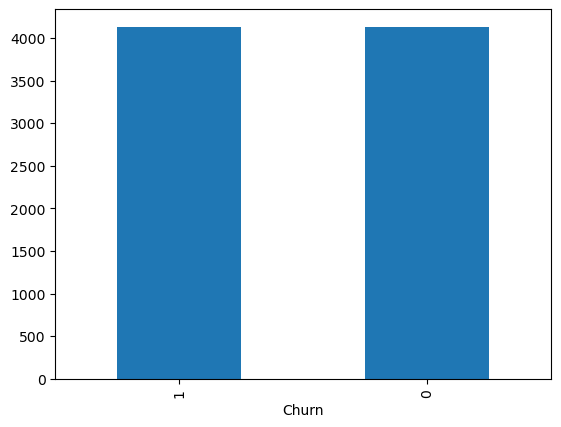

In [65]:
churn_plt = train_over["Churn"].value_counts()
churn_plt.plot(kind="bar")
plt.show()

## Oversampling

El conjunto de entrenamiento presentaba un desbalance entre las clases de la variable objetivo Churn.

Para corregir este problema se aplicó Oversampling sobre la clase minoritaria (clientes que abandonaron la compañía), generando nuevas observaciones mediante remuestreo con reemplazo.

Tras el proceso, ambas clases quedaron equilibradas, permitiendo entrenar modelos menos sesgados hacia la clase mayoritaria.

In [66]:
X_train_over = train_over.drop(columns=["Churn"])
y_train_over = train_over["Churn"]

In [67]:
log_reg_over = LogisticRegression(max_iter=1000)
log_reg_over.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
from sklearn.metrics import classification_report

In [70]:
pred = log_reg_over.predict(X_test_scaled)
print(classification_report(y_pred=pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Resultados tras Oversampling

Se entrenó nuevamente el modelo Logistic Regression utilizando el conjunto de datos balanceado.

Posteriormente se evaluó el rendimiento sobre el conjunto de prueba para analizar el impacto del balanceo de clases en las métricas de clasificación, especialmente Recall y F1-Score para la clase Churn.

## Resultados del Oversampling

Se aplicó Oversampling sobre la clase minoritaria (clientes que abandonaron la compañía) con el objetivo de equilibrar la distribución de clases.

Posteriormente se entrenó nuevamente un modelo Logistic Regression utilizando los datos balanceados.

El modelo mejoró su capacidad para detectar clientes con Churn, aumentando el recall de la clase positiva, aunque con una ligera reducción en la precisión global.

UNDERSAMPLING

In [71]:
train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train["Churn"] = y_train.values

In [72]:
churn = train[train["Churn"] == 1]
no_churn = train[train["Churn"] == 0]

In [73]:
no_churn_undersampled = resample(
    no_churn,
    replace=False,
    n_samples=len(churn),
    random_state=42
)

In [74]:
train_under = pd.concat([no_churn_undersampled, churn])

In [75]:
train_under["Churn"].value_counts()

Churn
0    1495
1    1495
Name: count, dtype: int64

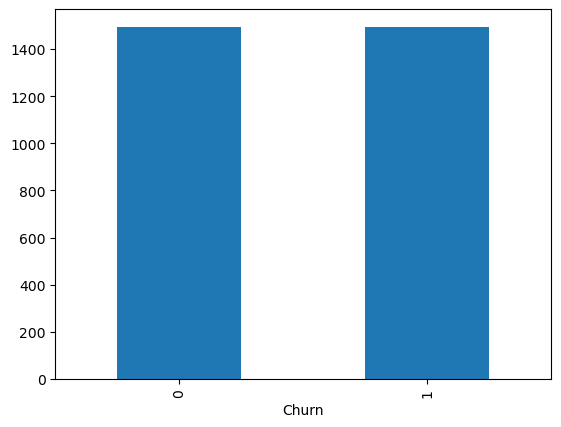

In [79]:
churn_plt = train_under["Churn"].value_counts()

churn_plt.plot(kind="bar")

plt.show()

## Undersampling

Se aplicó Undersampling sobre la clase mayoritaria (clientes sin abandono) reduciendo su tamaño hasta igualar el número de observaciones de la clase minoritaria.

Como resultado, ambas clases quedaron perfectamente balanceadas, permitiendo entrenar un modelo sin el sesgo generado por el desbalance original del dataset.

In [76]:
X_train_under = train_under.drop(columns=["Churn"])
y_train_under = train_under["Churn"]

In [77]:
log_reg_under = LogisticRegression(max_iter=1000)
log_reg_under.fit(X_train_under, y_train_under)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
pred = log_reg_under.predict(X_test_scaled)

print(classification_report(
    y_true=y_test,
    y_pred=pred
))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Resultados del Undersampling

Se aplicó Undersampling sobre la clase mayoritaria para equilibrar el conjunto de entrenamiento.

Tras entrenar nuevamente el modelo Logistic Regression, se observó una ligera mejora en el Recall de la clase Churn, aunque con una pequeña disminución en la precisión y en la exactitud global del modelo.

Los resultados obtenidos serán comparados posteriormente con SMOTE para determinar la mejor estrategia de balanceo.

In [80]:
from imblearn.over_sampling import SMOTE

In [81]:
sm = SMOTE(
    random_state=42,
    sampling_strategy=1.0
)

In [82]:
X_train_sm, y_train_sm = sm.fit_resample(
    X_train_scaled,
    y_train
)

In [83]:
y_train_sm.value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

SMOTE

## Aplicación de SMOTE

Se utilizó la técnica SMOTE (Synthetic Minority Oversampling Technique) para equilibrar las clases del conjunto de entrenamiento.

SMOTE genera nuevas observaciones sintéticas para la clase minoritaria utilizando la información de sus vecinos más cercanos, evitando la simple duplicación de registros.

Tras la aplicación de SMOTE, ambas clases quedaron perfectamente balanceadas.

In [84]:
from sklearn.linear_model import LogisticRegression

log_reg_sm = LogisticRegression(max_iter=1000)

log_reg_sm.fit(X_train_sm, y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [85]:
pred = log_reg_sm.predict(X_test_scaled)

print(
    classification_report(
        y_true=y_test,
        y_pred=pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



## Evaluación del Modelo con SMOTE

Tras aplicar SMOTE para equilibrar las clases mediante la generación de observaciones sintéticas, se entrenó nuevamente el modelo de Regresión Logística.

Los resultados muestran una mejora en la capacidad del modelo para identificar clientes que abandonan la compañía (Clase 1), alcanzando un Recall del 80%.

Esto indica que el balanceo de clases ayuda al modelo a detectar mejor los casos de churn, aunque se produce una ligera reducción en la precisión global.

## Comparación de Modelos

Para evaluar el impacto de las distintas técnicas de balanceo de clases, se comparó el rendimiento de la Regresión Logística base frente a Oversampling, Undersampling y SMOTE.

Se prestó especial atención al Recall de la clase Churn (1), ya que el objetivo principal del proyecto es identificar correctamente a los clientes con riesgo de abandono.

In [86]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Oversampling',
        'Undersampling',
        'SMOTE'
    ],
    'Accuracy': [
        0.79,
        0.74,
        0.73,
        0.74
    ],
    'Recall_Churn': [
        0.76,
        0.78,
        0.80,
        0.80
    ]
})

comparison

,Model,Accuracy,Recall_Churn
0,Logistic Regression,0.79,0.76
1,Oversampling,0.74,0.78
2,Undersampling,0.73,0.80
3,SMOTE,0.74,0.80


## Conclusiones del Balanceo de Clases

El modelo de Regresión Logística original obtuvo la mayor precisión global (Accuracy = 79%), aunque presentó una menor capacidad para detectar clientes que abandonan la compañía.

Las técnicas de balanceo mejoraron el Recall de la clase Churn, aumentando la detección de clientes con riesgo de abandono.

Undersampling y SMOTE alcanzaron el mejor Recall (80%), lo que los convierte en alternativas más adecuadas cuando el objetivo principal es identificar posibles casos de churn.